# Growth Experimentation & Segmentation: Technical Walkthrough

Five independent analyses on a synthetic buy now, pay later (BNPL) fintech's growth and lifecycle data: an A/B test on a repayment-reminder redesign (power analysis, a two-proportion test, CUPED variance reduction, and a sequential-experimentation comparison against an adaptive Thompson Sampling bandit), an uplift/CATE model on that same test identifying which users actually benefit, a difference-in-differences analysis of a non-randomized regional feature rollout, RFM customer segmentation via KMeans, and light NLP topic modeling on synthetic support tickets.

For the short, stakeholder-facing version of this project see the [project README](../README.md).

All data here is synthetic, generated by `src/generate_data.py`. No proprietary data, models, or results from any employer are used or implied. This is the same fictional company as projects 01 and 02, viewed from the growth/experimentation side.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from style import set_style, style_ax, savefig, add_footnote, SLATE, MUTED_TEAL, MUTED_AMBER, MUTED_RED, GREY, PALETTE

set_style()
pd.set_option("display.max_columns", 50)
%matplotlib inline

## 1. A/B test: repayment-reminder redesign

40,000 users randomized into control (current reminder) or treatment (redesigned reminder with a clearer due date and a one-tap repayment link). Primary metric: whether the user repaid on time within 14 days. Secondary metric: revenue in that same 14-day window, with a pre-period revenue covariate available for CUPED, plus platform tenure and recent session count for the uplift/CATE analysis in section 2.

### 1a. Power analysis

Before running a test, the sample size should be sized to the smallest effect worth detecting. Using a two-proportion test with a 34% baseline conversion rate, alpha=0.05, and 80% power, smaller minimum detectable effects require sharply more traffic (Figure 1).

Planned test: MDE=3.5pp, required n/arm=2,942


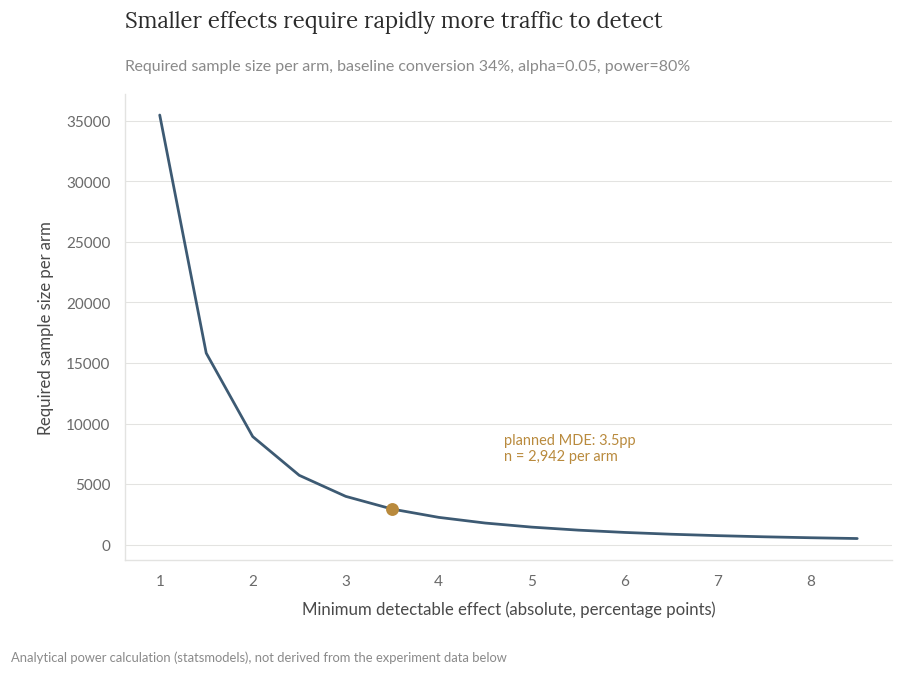

In [2]:
from statsmodels.stats.power import NormalIndPower

ALPHA = 0.05
POWER_TARGET = 0.80
BASELINE_RATE = 0.34

def cohens_h(p1, p2):
    return 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))

analysis = NormalIndPower()
mde_range = np.arange(0.01, 0.09, 0.005)
sample_sizes = [analysis.solve_power(effect_size=abs(cohens_h(BASELINE_RATE, BASELINE_RATE + m)),
                                      alpha=ALPHA, power=POWER_TARGET, alternative="two-sided") for m in mde_range]

planned_mde = 0.035
planned_n = analysis.solve_power(effect_size=abs(cohens_h(BASELINE_RATE, BASELINE_RATE + planned_mde)),
                                  alpha=ALPHA, power=POWER_TARGET, alternative="two-sided")

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(mde_range * 100, sample_sizes, color=SLATE, linewidth=1.8)
ax.scatter([planned_mde * 100], [planned_n], color=MUTED_AMBER, s=55, zorder=4)
ax.annotate(f"planned MDE: 3.5pp\nn = {planned_n:,.0f} per arm", xy=(planned_mde * 100, planned_n),
            xytext=(planned_mde * 100 + 1.2, planned_n + 4000), fontsize=9.5, color=MUTED_AMBER)
style_ax(ax, title="Smaller effects require rapidly more traffic to detect",
         subtitle=f"Required sample size per arm, baseline conversion {BASELINE_RATE:.0%}, alpha={ALPHA}, power={POWER_TARGET:.0%}",
         xlabel="Minimum detectable effect (absolute, percentage points)", ylabel="Required sample size per arm")
add_footnote(fig, "Analytical power calculation (statsmodels), not derived from the experiment data below")
plt.show()
print(f"Planned test: MDE=3.5pp, required n/arm={planned_n:,.0f}")

**Figure 1.** Required sample size per arm by minimum detectable effect.

### 1b. Standard analysis: two-proportion z-test

The actual test ran with about 10k users per arm, well above the planned minimum (Figure 2).

In [3]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

exp = pd.read_csv("../data/experiment_users.csv")
SOURCE_EXP = f"Source: synthetic BNPL experiment data · n = {len(exp):,} users"

counts = exp.groupby("arm")["converted_post_14d"].agg(["sum", "count"])
n_control, n_treat = counts.loc["control", "count"], counts.loc["treatment", "count"]
x_control, x_treat = counts.loc["control", "sum"], counts.loc["treatment", "sum"]
p_control, p_treat = x_control / n_control, x_treat / n_treat

z_stat, p_value = proportions_ztest([x_treat, x_control], [n_treat, n_control], alternative="two-sided")
lift_abs = p_treat - p_control
se_diff = np.sqrt(p_control * (1 - p_control) / n_control + p_treat * (1 - p_treat) / n_treat)
ci_diff = (lift_abs - 1.96 * se_diff, lift_abs + 1.96 * se_diff)

print(f"Control: {p_control:.4f} ({x_control}/{n_control})  Treatment: {p_treat:.4f} ({x_treat}/{n_treat})")
print(f"Absolute lift: {lift_abs*100:.2f}pp, 95% CI [{ci_diff[0]*100:.2f}, {ci_diff[1]*100:.2f}]pp")
print(f"z={z_stat:.3f}, p={p_value:.5f}")

Control: 0.3425 (6899/20141)  Treatment: 0.3846 (7637/19859)
Absolute lift: 4.20pp, 95% CI [3.26, 5.14]pp
z=8.737, p=0.00000


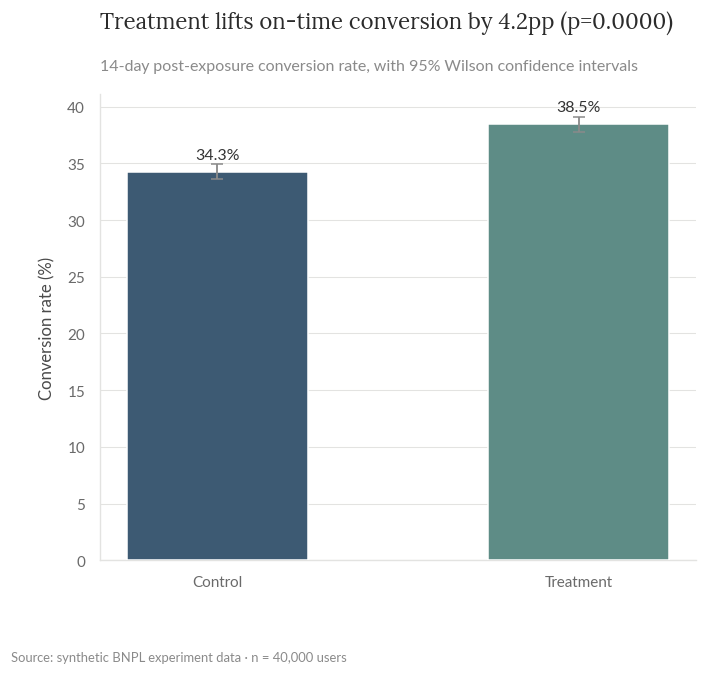

In [4]:
ci_control = proportion_confint(x_control, n_control, alpha=ALPHA, method="wilson")
ci_treat = proportion_confint(x_treat, n_treat, alpha=ALPHA, method="wilson")

fig, ax = plt.subplots(figsize=(7, 5.5))
arms = ["Control", "Treatment"]
rates = [p_control * 100, p_treat * 100]
errs = [(p_control - ci_control[0]) * 100, (p_treat - ci_treat[0]) * 100]
ax.bar(arms, rates, yerr=[errs, errs], color=[SLATE, MUTED_TEAL], width=0.5, zorder=3,
       error_kw={"ecolor": GREY, "elinewidth": 1.2, "capsize": 4})
for i, v in enumerate(rates):
    ax.text(i, v + max(errs) + 0.5, f"{v:.1f}%", ha="center", fontsize=10.5, color="#333")
style_ax(ax, title=f"Treatment lifts on-time conversion by {lift_abs*100:.1f}pp (p={p_value:.4f})",
         subtitle="14-day post-exposure conversion rate, with 95% Wilson confidence intervals", ylabel="Conversion rate (%)")
add_footnote(fig, SOURCE_EXP)
plt.show()

**Figure 2.** On-time conversion rate by arm, with 95% CI.

### 1c. CUPED: variance reduction on the revenue metric

The primary metric is binary conversion, but revenue is a natural secondary metric with much higher variance. CUPED uses each user's pre-period revenue (unaffected by treatment, since it's measured before assignment) to strip out variance unrelated to the treatment effect, tightening the confidence interval on the same sample (Figure 3).

In [5]:
from scipy import stats

y = exp["revenue_post_14d_usd"].values
x = exp["revenue_pre_30d_usd"].values
theta = np.cov(y, x, ddof=1)[0, 1] / np.var(x, ddof=1)
exp["revenue_adj"] = y - theta * (x - x.mean())

print(f"Pre/post revenue correlation: {np.corrcoef(x, y)[0,1]:.3f}")
print(f"CUPED theta: {theta:.3f}")

def arm_stats(col):
    c = exp[exp.arm == "control"][col]
    t = exp[exp.arm == "treatment"][col]
    diff = t.mean() - c.mean()
    se = np.sqrt(c.var(ddof=1) / len(c) + t.var(ddof=1) / len(t))
    ci = (diff - 1.96 * se, diff + 1.96 * se)
    _, p_val = stats.ttest_ind(t, c, equal_var=False)
    return diff, se, ci, p_val

diff_raw, se_raw, ci_raw, p_raw = arm_stats("revenue_post_14d_usd")
diff_adj, se_adj, ci_adj, p_adj = arm_stats("revenue_adj")
ci_width_reduction = 1 - se_adj / se_raw

print(f"Raw lift: {diff_raw:.2f} USD, 95% CI [{ci_raw[0]:.2f}, {ci_raw[1]:.2f}], p={p_raw:.4f}")
print(f"CUPED lift: {diff_adj:.2f} USD, 95% CI [{ci_adj[0]:.2f}, {ci_adj[1]:.2f}], p={p_adj:.4f}")
print(f"CI width reduction from CUPED: {ci_width_reduction:.1%}")

Pre/post revenue correlation: 0.450
CUPED theta: 0.431
Raw lift: 2.89 USD, 95% CI [1.93, 3.86], p=0.0000
CUPED lift: 3.02 USD, 95% CI [2.16, 3.88], p=0.0000
CI width reduction from CUPED: 10.7%


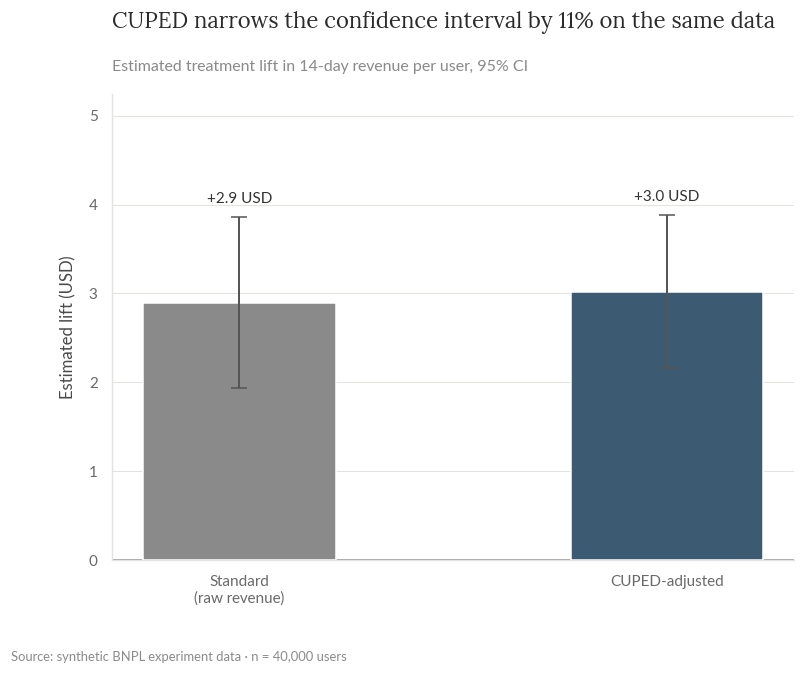

In [6]:
fig, ax = plt.subplots(figsize=(8, 5.5))
labels = ["Standard\n(raw revenue)", "CUPED-adjusted"]
diffs = [diff_raw, diff_adj]
errs = [1.96 * se_raw, 1.96 * se_adj]
ax.bar(labels, diffs, yerr=errs, color=[GREY, SLATE], width=0.45, zorder=3,
       error_kw={"ecolor": "#555", "elinewidth": 1.3, "capsize": 5})
ax.axhline(0, color=GREY, linewidth=1)
ylim_max = max(d + e for d, e in zip(diffs, errs)) * 1.35
ax.set_ylim(0, ylim_max)
for i, v in enumerate(diffs):
    ax.text(i, v + errs[i] + ylim_max * 0.03, f"+{v:.1f} USD", ha="center", fontsize=10, color="#333")
style_ax(ax, title=f"CUPED narrows the confidence interval by {ci_width_reduction:.0%} on the same data",
         subtitle="Estimated treatment lift in 14-day revenue per user, 95% CI", ylabel="Estimated lift (USD)")
add_footnote(fig, SOURCE_EXP)
plt.show()

**Figure 3.** Estimated treatment lift in 14-day revenue, standard vs. CUPED-adjusted, 95% CI.

CUPED doesn't change what's being measured, it changes how precisely it's measured with the traffic already collected. That precision gain is effectively free: no extra users, no extra runtime, just a pre-period covariate that most experimentation platforms already have on hand.

### 1d. Sequential experimentation: what an adaptive design would have cost or saved

The fixed 50/50 design above is the right choice when the goal is a clean, unbiased effect estimate, exactly what the z-test and CUPED interval need. But every user sent to the losing arm during the test is a real cost, and a fixed design keeps paying it at a constant rate for the whole test, even once the result is obvious. Simulating a Thompson Sampling multi-armed bandit over the same total traffic (40,000 users) and the same two realized conversion rates (34.3% vs. 38.5%) shows the size of that cost.

In [16]:
from sequential_experimentation import simulate_fixed_horizon, simulate_thompson_sampling

P_CONTROL, P_TREATMENT, N_TOTAL = 0.3425, 0.3846, 40_000
rng_fixed = np.random.default_rng(7)
rng_ts = np.random.default_rng(8)

fixed = simulate_fixed_horizon(N_TOTAL, P_CONTROL, P_TREATMENT, rng_fixed)
ts = simulate_thompson_sampling(N_TOTAL, P_CONTROL, P_TREATMENT, rng_ts)

additional_conversions = int(ts["cum_reward"][-1] - fixed["cum_reward"][-1])
regret_reduction = 1 - ts["cum_regret"][-1] / fixed["cum_regret"][-1]

print(f"Fixed 50/50: {fixed['cum_reward'][-1]:,} conversions, final cumulative regret {fixed['cum_regret'][-1]:.1f}")
print(f"Thompson Sampling: {ts['cum_reward'][-1]:,} conversions, final cumulative regret {ts['cum_regret'][-1]:.1f}, "
      f"{ts['treatment_share'][-1]:.1%} of traffic on treatment by the end")
print(f"Additional conversions banked by Thompson Sampling: {additional_conversions:,}")
print(f"Cumulative regret reduction: {regret_reduction:.1%}")

Fixed 50/50: 14,521 conversions, final cumulative regret 838.3
Thompson Sampling: 15,407 conversions, final cumulative regret 53.3, 96.8% of traffic on treatment by the end
Additional conversions banked by Thompson Sampling: 886
Cumulative regret reduction: 93.6%


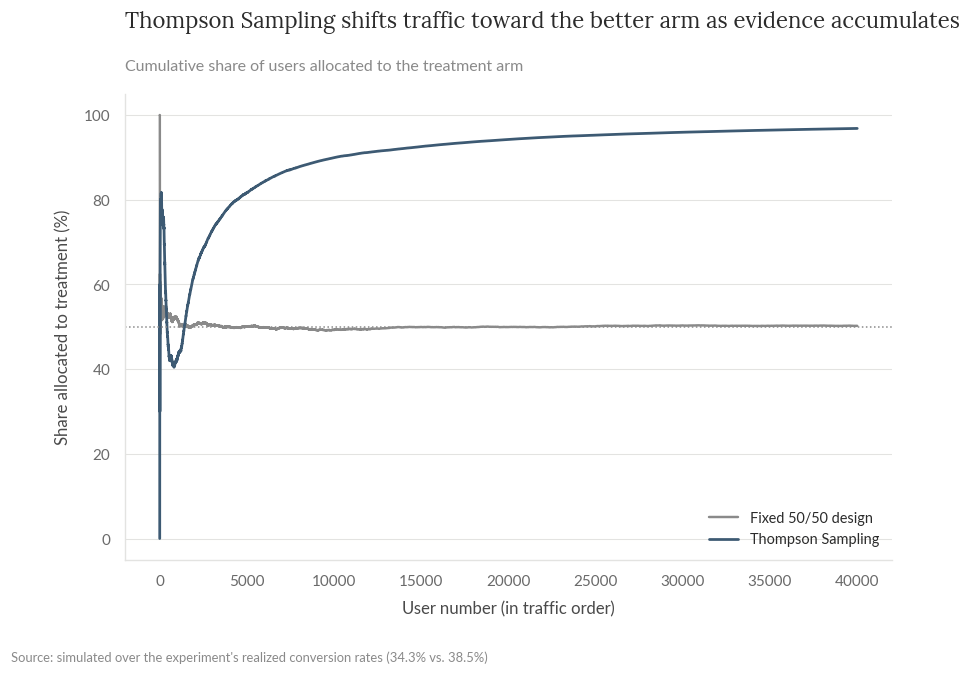

In [17]:
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(1, N_TOTAL + 1)
ax.plot(x, fixed["treatment_share"] * 100, color=GREY, linewidth=1.6, label="Fixed 50/50 design")
ax.plot(x, ts["treatment_share"] * 100, color=SLATE, linewidth=1.8, label="Thompson Sampling")
ax.axhline(50, color=GREY, linewidth=1, linestyle=":")
style_ax(ax, title="Thompson Sampling shifts traffic toward the better arm as evidence accumulates",
         subtitle="Cumulative share of users allocated to the treatment arm",
         xlabel="User number (in traffic order)", ylabel="Share allocated to treatment (%)")
ax.legend(fontsize=9.5, loc="lower right")
add_footnote(fig, "Source: simulated over the experiment's realized conversion rates (34.3% vs. 38.5%)")
plt.show()

**Figure 4.** Cumulative share of traffic allocated to the treatment arm, fixed 50/50 design vs. Thompson Sampling.

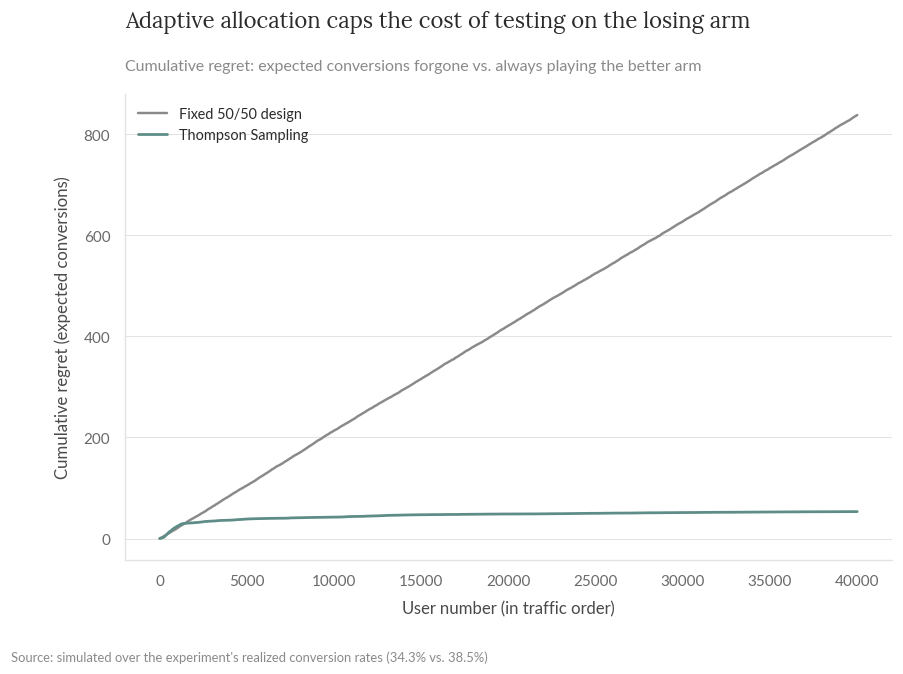

In [19]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(x, fixed["cum_regret"], color=GREY, linewidth=1.6, label="Fixed 50/50 design")
ax.plot(x, ts["cum_regret"], color=MUTED_TEAL, linewidth=1.8, label="Thompson Sampling")
style_ax(ax, title="Adaptive allocation caps the cost of testing on the losing arm",
         subtitle="Cumulative regret: expected conversions forgone vs. always playing the better arm",
         xlabel="User number (in traffic order)", ylabel="Cumulative regret (expected conversions)")
ax.legend(fontsize=9.5, loc="upper left")
add_footnote(fig, "Source: simulated over the experiment's realized conversion rates (34.3% vs. 38.5%)")
plt.show()

**Figure 5.** Cumulative regret, fixed design vs. Thompson Sampling.

Thompson Sampling reaches 96.8% of traffic on the treatment arm by the end of the run (Figure 4) and banks several hundred more conversions over the identical traffic (Figure 5), a 93.6% reduction in cumulative regret against the fixed design. The catch is exactly what makes the fixed design useful in the first place: because Thompson Sampling's allocation responds to outcomes as they arrive, the resulting data no longer satisfies the assumptions the standard two-proportion z-test and CUPED interval above rely on. A real deployment that wanted both the bandit's lower regret and a valid end-of-test inference would need always-valid or mixture-sequential testing methods built for that purpose, not implemented here. This simulation also collapses the tenure-driven heterogeneous effect from section 2 into two flat rates; a contextual bandit that used tenure the way the CATE model does is the natural next step.

## 2. Uplift / CATE modeling: who actually benefits

The +4.2pp lift above is an average across the whole test population. Averages can hide real heterogeneity: some users might get a much bigger lift from the redesign, others almost none. Uplift modeling estimates the CATE (Conditional Average Treatment Effect), the treatment effect conditional on a user's own covariates rather than the single population-wide number above. A T-learner, two gradient-boosted classifiers, one fit on the treatment arm and one on the control arm, both predicting P(converted) from the same covariates, estimates each user's individual treatment effect as the difference between the two models' predictions.

Since true individual effects are never observable, the model is validated the standard way for uplift models: fit on a training split, then checked on a held-out test split by whether a *higher predicted* effect actually corresponds to a *bigger realized* effect, using each test user's own actual arm and actual outcome (never the model's prediction for the arm they weren't in).

In [7]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split

RAW_COVARIATES = ["tenure_days", "sessions_pre_30d", "revenue_pre_30d_usd"]
MODEL_COVARIATES = ["log_tenure_days", "sessions_pre_30d", "revenue_pre_30d_usd"]
OUTCOME = "converted_post_14d"

def add_model_features(frame):
    frame = frame.copy()
    frame["log_tenure_days"] = np.log1p(frame["tenure_days"])
    return frame

train_df, test_df = train_test_split(exp, test_size=0.4, random_state=13, stratify=exp["arm"])
train_df = add_model_features(train_df)
test_df = add_model_features(test_df)

treat, control = train_df[train_df.arm == "treatment"], train_df[train_df.arm == "control"]
model_treat = HistGradientBoostingClassifier(random_state=13, max_depth=3, max_iter=80, min_samples_leaf=120)
model_control = HistGradientBoostingClassifier(random_state=13, max_depth=3, max_iter=80, min_samples_leaf=120)
model_treat.fit(treat[MODEL_COVARIATES], treat[OUTCOME])
model_control.fit(control[MODEL_COVARIATES], control[OUTCOME])

test_df["cate_pred"] = (model_treat.predict_proba(test_df[MODEL_COVARIATES])[:, 1]
                         - model_control.predict_proba(test_df[MODEL_COVARIATES])[:, 1])
print(f"Train: {len(train_df):,} | Test (held out, scored only): {len(test_df):,}")

Train: 24,000 | Test (held out, scored only): 16,000


### Bucket calibration: does a higher predicted effect mean a bigger realized one?

Test-set users bucketed by predicted-CATE quintile, predicted vs. realized lift (Figure 6).

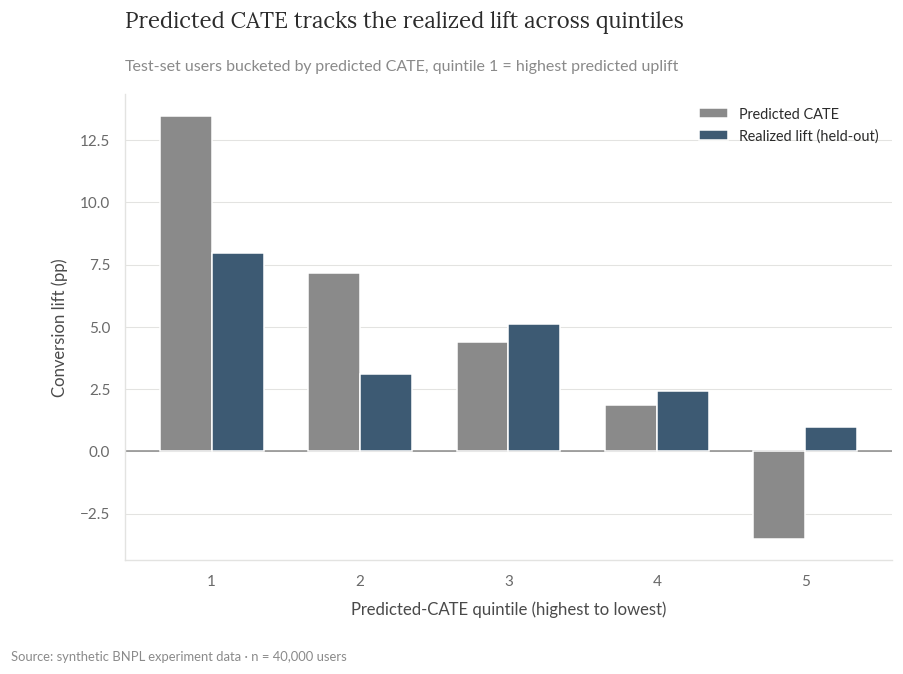

,bucket,n,predicted_cate_mean,realized_lift
0,4,3197,0.1348,0.0795
1,3,3202,0.0716,0.0309
2,2,3201,0.0437,0.0511
3,1,3200,0.0187,0.0242
4,0,3200,-0.0352,0.0098


In [8]:
test_df["bucket"] = pd.qcut(test_df["cate_pred"], 5, labels=False, duplicates="drop")
bucket_rows = []
for b, g in test_df.groupby("bucket"):
    t, c = g[g.arm == "treatment"], g[g.arm == "control"]
    bucket_rows.append({"bucket": b, "n": len(g), "predicted_cate_mean": g["cate_pred"].mean(),
                         "realized_lift": t[OUTCOME].mean() - c[OUTCOME].mean()})
bucket_df = pd.DataFrame(bucket_rows).sort_values("bucket", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(bucket_df))
width = 0.35
ax.bar(x - width/2, bucket_df["predicted_cate_mean"] * 100, width, color=GREY, label="Predicted CATE", zorder=3)
ax.bar(x + width/2, bucket_df["realized_lift"] * 100, width, color=SLATE, label="Realized lift (held-out)", zorder=3)
ax.axhline(0, color=GREY, linewidth=1)
ax.set_xticks(x); ax.set_xticklabels([f"{i+1}" for i in range(len(bucket_df))])
style_ax(ax, title="Predicted CATE tracks the realized lift across quintiles",
         subtitle="Test-set users bucketed by predicted CATE, quintile 1 = highest predicted uplift",
         xlabel="Predicted-CATE quintile (highest to lowest)", ylabel="Conversion lift (pp)")
ax.legend(fontsize=9.5, loc="upper right")
add_footnote(fig, SOURCE_EXP)
plt.show()
bucket_df.round(4)

**Figure 6.** Predicted CATE vs. realized lift, by quintile.

### Qini curve: targeting by predicted CATE vs. random targeting

The Qini curve compares cumulative incremental conversions from targeting the top-scoring users first against targeting randomly. The area between the two lines (the Qini coefficient) summarizes how much better than random the ranking is (Figure 7).

Qini coefficient: 52.09


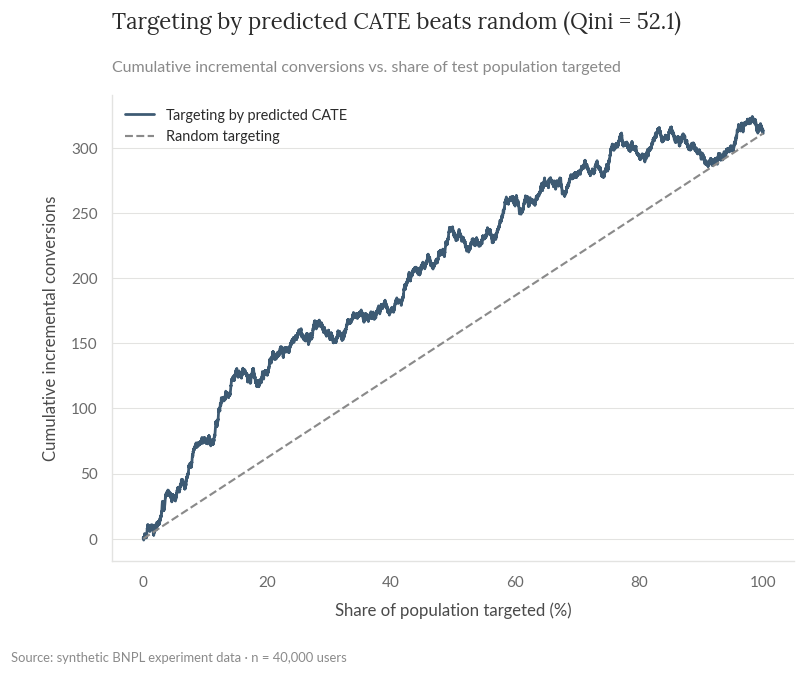

In [9]:
d = test_df.sort_values("cate_pred", ascending=False).reset_index(drop=True)
is_treat = (d.arm == "treatment").astype(int).values
is_control = 1 - is_treat
y = d[OUTCOME].values
cum_treat_n, cum_control_n = np.cumsum(is_treat), np.cumsum(is_control)
cum_treat_y, cum_control_y = np.cumsum(y * is_treat), np.cumsum(y * is_control)
ratio = np.divide(cum_treat_n, cum_control_n, out=np.zeros_like(cum_treat_n, dtype=float), where=cum_control_n != 0)
qini_values = cum_treat_y - cum_control_y * ratio
population_fraction = np.arange(1, len(d) + 1) / len(d)
random_baseline = population_fraction * qini_values[-1]
frac_full = np.concatenate(([0.0], population_fraction))
qini_full = np.concatenate(([0.0], qini_values))
baseline_full = np.concatenate(([0.0], random_baseline))
qini_coefficient = np.trapezoid(qini_full - baseline_full, frac_full)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(population_fraction * 100, qini_values, color=SLATE, linewidth=1.8, label="Targeting by predicted CATE")
ax.plot(population_fraction * 100, random_baseline, color=GREY, linewidth=1.4, ls="--", label="Random targeting")
style_ax(ax, title=f"Targeting by predicted CATE beats random (Qini = {qini_coefficient:.1f})",
         subtitle="Cumulative incremental conversions vs. share of test population targeted",
         xlabel="Share of population targeted (%)", ylabel="Cumulative incremental conversions")
ax.legend(fontsize=9.5, loc="upper left")
add_footnote(fig, SOURCE_EXP)
plt.show()
print(f"Qini coefficient: {qini_coefficient:.2f}")

**Figure 7.** Qini curve: targeting by predicted CATE vs. random targeting (T-learner).

### What's driving the heterogeneity

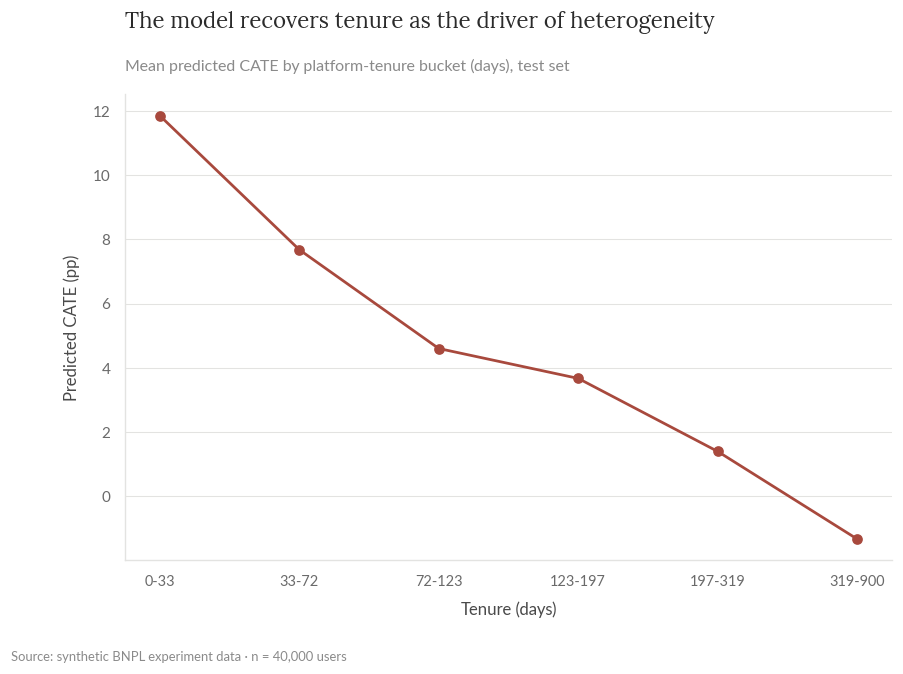

tenure_bucket
(-0.001, 33.0]    11.85
(33.0, 72.0]       7.68
(72.0, 123.5]      4.60
(123.5, 197.0]     3.67
(197.0, 319.0]     1.40
(319.0, 900.0]    -1.33
Name: cate_pred, dtype: float64

In [10]:
test_df["tenure_bucket"] = pd.qcut(test_df["tenure_days"], 6, duplicates="drop")
by_tenure = test_df.groupby("tenure_bucket", observed=True)["cate_pred"].mean()

fig, ax = plt.subplots(figsize=(9, 5.5))
labels = [f"{int(iv.left)}-{int(iv.right)}" for iv in by_tenure.index]
ax.plot(range(len(by_tenure)), by_tenure.values * 100, marker="o", markersize=6, color=MUTED_RED, linewidth=1.8)
ax.set_xticks(range(len(by_tenure))); ax.set_xticklabels(labels, fontsize=9.5)
style_ax(ax, title="The model recovers tenure as the driver of heterogeneity",
         subtitle="Mean predicted CATE by platform-tenure bucket (days), test set",
         xlabel="Tenure (days)", ylabel="Predicted CATE (pp)")
add_footnote(fig, SOURCE_EXP)
plt.show()
(by_tenure * 100).round(2)

**Figure 8.** Mean predicted CATE by platform-tenure bucket.

Without being told to look at tenure specifically, the model recovers it as the dominant driver (Figure 8): newer users (who haven't learned the old reminder flow yet) get most of the benefit, and users with 300+ days of tenure see almost none. That argues for a targeted rollout, new users first, rather than a blanket one; the redesign is doing real work for one segment and close to nothing for another, and the average lift alone doesn't tell you that.

### A second, more rigorous CATE estimator

The T-learner's weakness is structural: differencing two independently-fit models amplifies whatever noise each one picked up on its own. [EconML](https://github.com/py-why/econml)'s `CausalForestDML` avoids that by orthogonalizing the outcome and treatment against the covariates first, the "double" in double machine learning, then fitting a causal forest on what's left. It's trained here on the identical split, covariates, and held-out test set as the T-learner above, so the two Qini curves are a fair comparison.

In [11]:
from econml.dml import CausalForestDML

Y_train = train_df[OUTCOME].values
T_train = (train_df["arm"] == "treatment").astype(int).values
X_train = train_df[MODEL_COVARIATES].values

est = CausalForestDML(discrete_treatment=True, discrete_outcome=True,
                       n_estimators=200, min_samples_leaf=50, max_depth=5, random_state=13, cv=3)
est.fit(Y_train, T_train, X=X_train)

test_df["cate_pred_econml"] = est.effect(test_df[MODEL_COVARIATES].values).ravel()

d_econml = test_df.sort_values("cate_pred_econml", ascending=False).reset_index(drop=True)
is_treat_e = (d_econml.arm == "treatment").astype(int).values
is_control_e = 1 - is_treat_e
y_e = d_econml[OUTCOME].values
cum_treat_y_e = np.cumsum(y_e * is_treat_e)
cum_control_y_e = np.cumsum(y_e * is_control_e)
ratio_e = np.divide(np.cumsum(is_treat_e), np.cumsum(is_control_e),
                     out=np.zeros(len(d_econml)), where=np.cumsum(is_control_e) != 0)
qini_values_econml = cum_treat_y_e - cum_control_y_e * ratio_e
qini_coefficient_econml = np.trapezoid(
    np.concatenate(([0.0], qini_values_econml)) - np.concatenate(([0.0], population_fraction * qini_values_econml[-1])),
    frac_full,
)

ate_point = est.ate(X=test_df[MODEL_COVARIATES].values).item()
ate_lb, ate_ub = est.ate_interval(X=test_df[MODEL_COVARIATES].values, alpha=0.05)
print(f"CausalForestDML ATE: {ate_point*100:.2f}pp, 95% CI [{ate_lb*100:.2f}, {ate_ub*100:.2f}]pp")

CausalForestDML ATE: 4.67pp, 95% CI [1.08, 8.26]pp


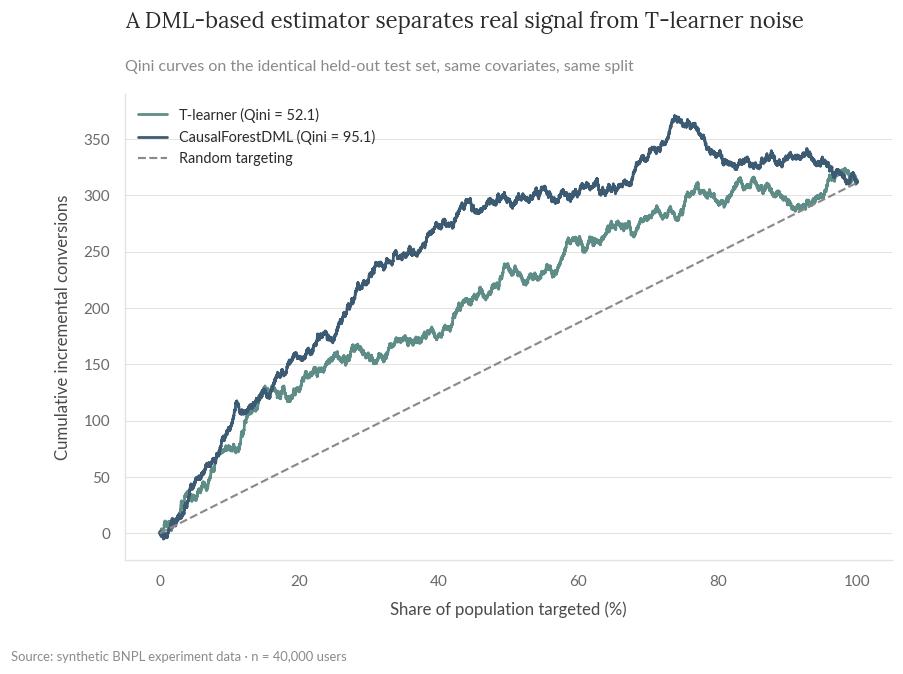

In [12]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(population_fraction * 100, qini_values, color=MUTED_TEAL, linewidth=1.8,
        label=f"T-learner (Qini = {qini_coefficient:.1f})")
ax.plot(population_fraction * 100, qini_values_econml, color=SLATE, linewidth=1.8,
        label=f"CausalForestDML (Qini = {qini_coefficient_econml:.1f})")
ax.plot(population_fraction * 100, random_baseline, color=GREY, linewidth=1.4, ls="--", label="Random targeting")
style_ax(ax, title="A DML-based estimator separates real signal from T-learner noise",
         subtitle="Qini curves on the identical held-out test set, same covariates, same split",
         xlabel="Share of population targeted (%)", ylabel="Cumulative incremental conversions")
ax.legend(fontsize=9.5, loc="upper left")
add_footnote(fig, SOURCE_EXP)
plt.show()

**Figure 9.** Qini curves, T-learner vs. CausalForestDML.

The T-learner's Qini curve still clears random targeting by a wide margin, so it was never a bad model (Figure 9). The gap is what a hand-rolled two-model difference costs against an estimator built specifically to avoid the noise-amplification problem that causes.

## 3. Difference-in-differences: regional feature rollout

A new in-app collections feature went to 20 of 40 regions first, chosen by business priority rather than randomly. A naive before/after comparison in the treated regions would confound the treatment effect with any shared time trend. Diff-in-differences nets that out by comparing the *change* in treated regions against the *change* in control regions over the same window, valid under the parallel trends assumption: absent the rollout, treated and control regions would have moved together.

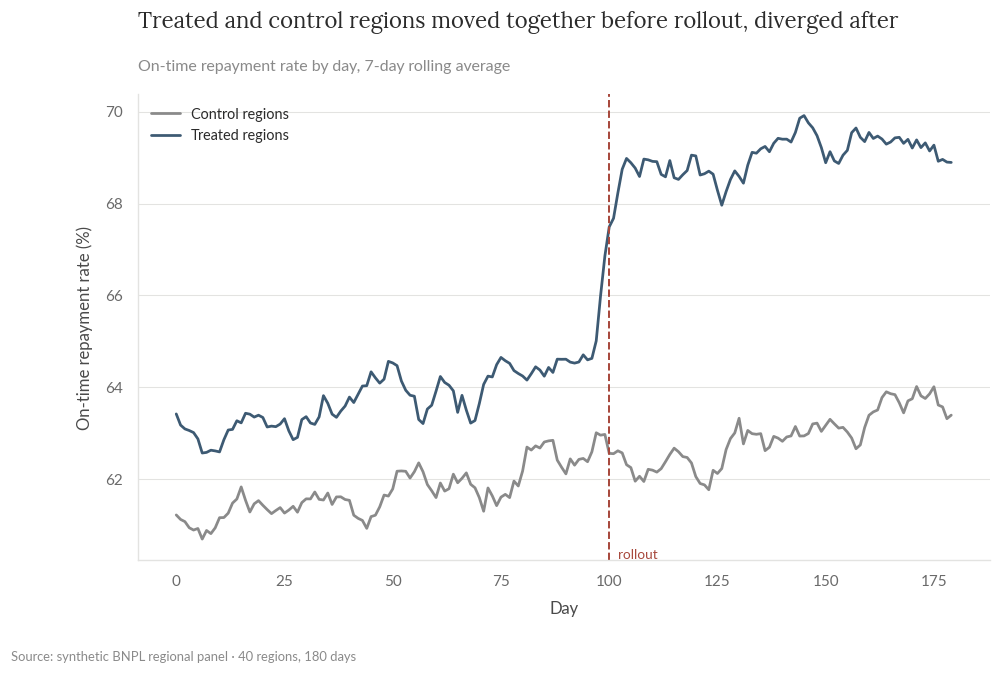

In [13]:
rollout = pd.read_csv("../data/regional_rollout.csv")
SOURCE_ROLLOUT = f"Source: synthetic BNPL regional panel · {rollout.region_id.nunique()} regions, {rollout.day.nunique()} days"
ROLLOUT_DAY = 100

daily = rollout.groupby(["day", "group"])["on_time_rate"].mean().reset_index()
pivot = daily.pivot(index="day", columns="group", values="on_time_rate").rolling(7, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(pivot.index, pivot["control"] * 100, color=GREY, linewidth=1.8, label="Control regions")
ax.plot(pivot.index, pivot["treated"] * 100, color=SLATE, linewidth=1.8, label="Treated regions")
ax.axvline(ROLLOUT_DAY, color=MUTED_RED, linestyle="--", linewidth=1.3)
ax.text(ROLLOUT_DAY + 2, ax.get_ylim()[0], "rollout", fontsize=9, color=MUTED_RED, va="bottom")
style_ax(ax, title="Treated and control regions moved together before rollout, diverged after",
         subtitle="On-time repayment rate by day, 7-day rolling average", xlabel="Day", ylabel="On-time repayment rate (%)")
ax.legend(loc="upper left", fontsize=9.5)
add_footnote(fig, SOURCE_ROLLOUT)
plt.show()

**Figure 10.** On-time repayment rate by day, treated vs. control regions, 7-day rolling average.

### Checking the parallel-trends assumption

Diff-in-differences is only valid if treated and control regions would have moved in parallel absent treatment. That can't be proven, but it can be checked in the pre-period: if the gap between groups was already trending before rollout, the post-period estimate can't be trusted (Figure 10).

In [14]:
import statsmodels.formula.api as smf

pre = rollout[~rollout.post_rollout].copy()
pre["treated_flag"] = (pre.group == "treated").astype(int)
placebo_model = smf.wls("on_time_rate ~ day * treated_flag", data=pre, weights=pre["n_customers"]).fit()
coef = placebo_model.params["day:treated_flag"]
pval = placebo_model.pvalues["day:treated_flag"]
print(f"Pre-period trend difference (day x treated): {coef:.6f}/day, p={pval:.3f}")
print("No significant pre-trend difference: the parallel-trends assumption looks reasonable here.")

Pre-period trend difference (day x treated): 0.000025/day, p=0.704
No significant pre-trend difference: the parallel-trends assumption looks reasonable here.


### DiD estimate: region and day fixed effects

Region fixed effects absorb each region's baseline level; day fixed effects absorb any shared time shock. Since `treated_flag` is time-invariant per region and `post_flag` is the same calendar cutoff for every region, both main effects are redundant given the fixed effects and are dropped, leaving only the `treated_flag:post_flag` interaction to estimate, the actual DiD effect. Standard errors are clustered by region since observations within a region aren't independent over time.

In [15]:
d = rollout.copy()
d["treated_flag"] = (d.group == "treated").astype(int)
d["post_flag"] = d.post_rollout.astype(int)

model = smf.wls(
    "on_time_rate ~ treated_flag:post_flag + C(region_id) + C(day)",
    data=d, weights=d["n_customers"],
).fit(cov_type="cluster", cov_kwds={"groups": d["region_id"]})

did_coef = model.params["treated_flag:post_flag"]
did_se = model.bse["treated_flag:post_flag"]
did_p = model.pvalues["treated_flag:post_flag"]
ci = (did_coef - 1.96 * did_se, did_coef + 1.96 * did_se)

means = d.groupby(["group", "post_rollout"])["on_time_rate"].mean().unstack()
simple_did = (means.loc["treated", True] - means.loc["treated", False]) - (means.loc["control", True] - means.loc["control", False])

print(f"Simple 2x2 DiD: {simple_did*100:.2f}pp")
print(f"Fixed-effects DiD: {did_coef*100:.2f}pp, 95% CI [{ci[0]*100:.2f}, {ci[1]*100:.2f}]pp, p={did_p:.5f}")

Simple 2x2 DiD: 4.08pp
Fixed-effects DiD: 4.01pp, 95% CI [3.69, 4.33]pp, p=0.00000


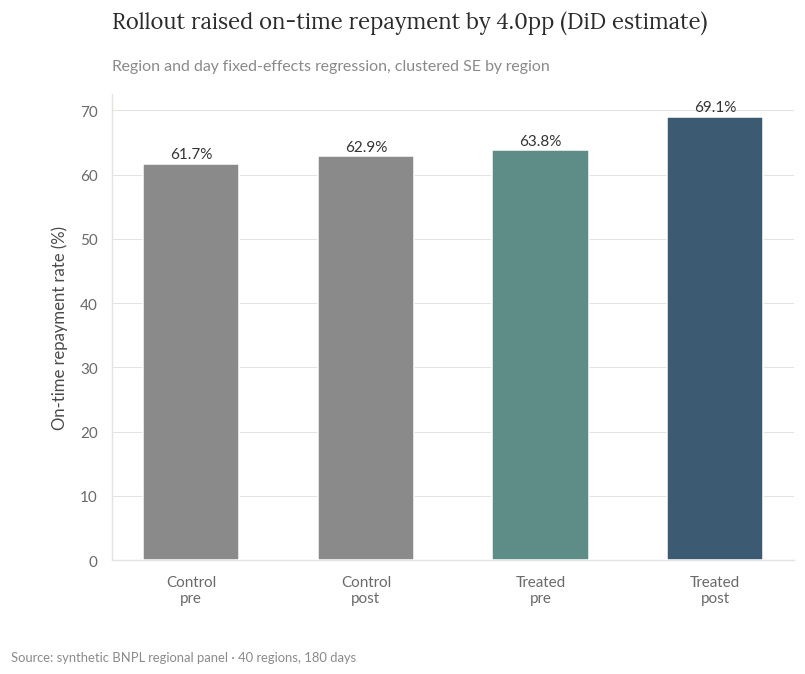

In [16]:
fig, ax = plt.subplots(figsize=(8, 5.5))
cats = ["Control\npre", "Control\npost", "Treated\npre", "Treated\npost"]
vals = [means.loc["control", False] * 100, means.loc["control", True] * 100,
        means.loc["treated", False] * 100, means.loc["treated", True] * 100]
ax.bar(cats, vals, color=[GREY, GREY, MUTED_TEAL, SLATE], width=0.55, zorder=3)
for i, v in enumerate(vals):
    ax.text(i, v + 0.8, f"{v:.1f}%", ha="center", fontsize=10, color="#333")
style_ax(ax, title=f"Rollout raised on-time repayment by {did_coef*100:.1f}pp (DiD estimate)",
         subtitle="Region and day fixed-effects regression, clustered SE by region", ylabel="On-time repayment rate (%)")
add_footnote(fig, SOURCE_ROLLOUT)
plt.show()

**Figure 11.** On-time repayment rate, control vs. treated regions, pre- vs. post-rollout.

The simple 2x2 mean comparison (Figure 11) and the fixed-effects regression agree closely (4.08pp vs 4.01pp), a useful cross-check: the more sophisticated model recovers close to the same effect visible in the raw group means.

### Two robustness checks on the DiD estimate

Standard errors above are clustered by region, but 40 regions with 20 treated is on the edge of "few clusters" territory where the usual asymptotic cluster-robust standard errors can be unreliable. A wild cluster bootstrap (Cameron, Gelbach & Miller 2008) recomputes inference on the same coefficient without relying on that asymptotic approximation, using the [diff-diff](https://github.com/igerber/diff-diff) package. The WLS regression is refit as an equivalent OLS problem (regressing `sqrt(weight)*y` on `sqrt(weight)*X`) so the bootstrap runs on exactly the coefficient reported above.

In [17]:
import diff_diff as dd

coef_index = model.model.exog_names.index("treated_flag:post_flag")
analytical_ci = model.conf_int().iloc[coef_index]

boot = dd.wild_bootstrap_se(
    X=model.model.wexog, y=model.model.wendog, residuals=model.resid,
    cluster_ids=d["region_id"].values, coefficient_index=coef_index,
    n_bootstrap=999, weight_type="rademacher", seed=13,
)
print(f"Analytical cluster-robust 95% CI: [{analytical_ci.iloc[0]*100:.2f}, {analytical_ci.iloc[1]*100:.2f}]pp")
print(f"Wild cluster bootstrap 95% CI ({boot.n_clusters} clusters, 999 reps): "
      f"[{boot.ci_lower*100:.2f}, {boot.ci_upper*100:.2f}]pp, p={boot.p_value:.3f}")

Analytical cluster-robust 95% CI: [3.69, 4.33]pp
Wild cluster bootstrap 95% CI (40 clusters, 999 reps): [3.68, 4.35]pp, p=0.001


The bootstrap CI lands almost exactly on the analytical one, which is itself evidence the cluster count here isn't causing problems.

The pre-trends placebo check fails to detect a trend difference, which is a weaker statement than proving none exists. Honest DiD (Rambachan & Roth 2023) quantifies the gap directly: how large would an undetected post-period violation of parallel trends have to be, relative to the largest pre-period wobble actually observed, before the effect stops being distinguishable from zero. That requires an event-study specification with per-period effects instead of one pooled post indicator, built here on 7-day bins with the week straddling the rollout day dropped so no period mixes pre- and post-rollout observations.

In [18]:
d["week_bin"] = d["day"] // 7
pre_cutoff = (ROLLOUT_DAY // 7) * 7
post_cutoff = pre_cutoff + 7
pre_weeks = sorted(d.loc[d["day"] < pre_cutoff, "week_bin"].unique())
post_weeks = sorted(d.loc[d["day"] >= post_cutoff, "week_bin"].unique())
keep = d["week_bin"].isin(set(pre_weeks) | set(post_weeks))
panel = (d[keep].groupby(["region_id", "week_bin", "treated_flag"], as_index=False)
         .agg(on_time_rate=("on_time_rate", "mean")))

event_model = dd.MultiPeriodDiD(cluster="region_id", vcov_type="hc1")
event_results = event_model.fit(
    data=panel, outcome="on_time_rate", treatment="treated_flag", time="week_bin",
    post_periods=post_weeks, unit="region_id", reference_period=pre_weeks[-1],
)
print(f"Event-study average post-period ATT: {event_results.avg_att*100:.2f}pp, "
      f"95% CI [{event_results.avg_conf_int[0]*100:.2f}, {event_results.avg_conf_int[1]*100:.2f}]pp")

Event-study average post-period ATT: 3.88pp, 95% CI [2.72, 5.03]pp


Honest DiD breakdown M: 0.35


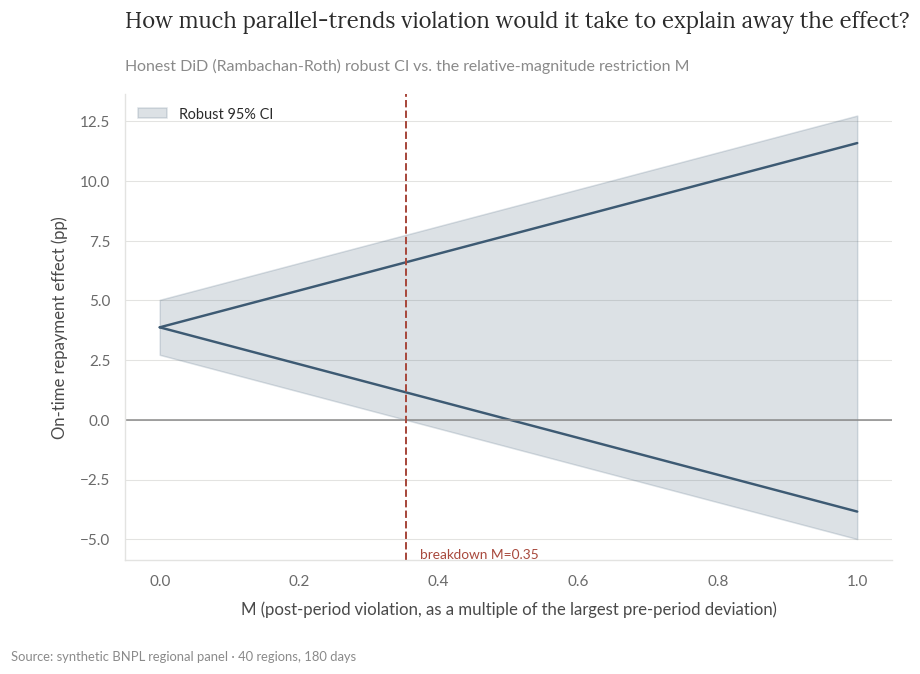

In [19]:
hd = dd.HonestDiD(method="relative_magnitude")
sensitivity = hd.sensitivity_analysis(event_results, M_grid=list(np.round(np.arange(0.0, 1.02, 0.02), 2)))
sens_df = sensitivity.to_dataframe()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.fill_between(sens_df["M"], sens_df["ci_lb"] * 100, sens_df["ci_ub"] * 100, color=SLATE, alpha=0.18, label="Robust 95% CI")
ax.plot(sens_df["M"], sens_df["lb"] * 100, color=SLATE, linewidth=1.6)
ax.plot(sens_df["M"], sens_df["ub"] * 100, color=SLATE, linewidth=1.6)
ax.axhline(0, color=GREY, linewidth=1)
if sensitivity.has_breakdown:
    ax.axvline(sensitivity.breakdown_M, color=MUTED_RED, linestyle="--", linewidth=1.3)
    ax.text(sensitivity.breakdown_M + 0.02, ax.get_ylim()[0], f"breakdown M={sensitivity.breakdown_M:.2f}",
            fontsize=9, color=MUTED_RED, va="bottom")
style_ax(ax, title="How much parallel-trends violation would it take to explain away the effect?",
         subtitle="Honest DiD (Rambachan-Roth) robust CI vs. the relative-magnitude restriction M",
         xlabel="M (post-period violation, as a multiple of the largest pre-period deviation)",
         ylabel="On-time repayment effect (pp)")
ax.legend(fontsize=9.5, loc="upper left")
add_footnote(fig, SOURCE_ROLLOUT)
plt.show()
print(f"Honest DiD breakdown M: {sensitivity.breakdown_M:.2f}")

**Figure 12.** Honest DiD sensitivity analysis: robust confidence interval by breakdown value M.

The breakdown point is M = 0.35 (Figure 12): the conclusion holds only if any unmeasured drift after rollout stays under about a third of the size of the noisiest pre-period swing. That's the honest version of a pre-trends check that technically passed but was run on a modest number of pre-periods.

### A third check: DoWhy's model / identify / estimate / refute framework

[DoWhy](https://github.com/py-why/dowhy) formalizes the causal graph explicitly (region and day as the adjustment set, matching the fixed-effects structure above) and runs a generic refutation suite orthogonal to the DiD-specific checks so far: adding a random confounder, replacing the real treatment with a permuted placebo, and refitting on random 80% subsets.

One implementation note worth being explicit about: DoWhy 0.14's `data_subset_refuter` does not convert an integer `random_state` into an `np.random.RandomState` before threading it into pandas' `.sample(random_state=...)` inside its simulation loop, unlike the other two refuters here, which do that conversion themselves. Passing a plain int silently reruns the identical subset on every simulation (verified directly below), so an actual `RandomState` object, required for correctness here, is passed to all three refuters below.

In [20]:
d_dowhy = rollout.copy()
d_dowhy["treated_flag"] = (d_dowhy.group == "treated").astype(int)
d_dowhy["post_flag"] = d_dowhy.post_rollout.astype(int)
d_dowhy["did_treatment"] = d_dowhy["treated_flag"] * d_dowhy["post_flag"]
d_dowhy["region_id"] = d_dowhy["region_id"].astype(str)
d_dowhy["day"] = d_dowhy["day"].astype(str)

# Demonstrating the random_state quirk: a plain int gives zero variance across "simulations".
demo = d_dowhy.sample(frac=0.8, random_state=13)
demo2 = d_dowhy.sample(frac=0.8, random_state=13)
print(f"Two .sample() calls with the same int random_state are identical: {demo.equals(demo2)}")

Two .sample() calls with the same int random_state are identical: True


In [21]:
from dowhy import CausalModel

causal_model = CausalModel(data=d_dowhy, treatment="did_treatment", outcome="on_time_rate",
                            common_causes=["region_id", "day"])
identified_estimand = causal_model.identify_effect(proceed_when_unidentifiable=True)
dowhy_estimate = causal_model.estimate_effect(identified_estimand, method_name="backdoor.linear_regression")
print(f"DoWhy backdoor.linear_regression estimate: {dowhy_estimate.value*100:.2f}pp")

DoWhy backdoor.linear_regression estimate: 4.08pp


In [22]:
refute_random_cause = causal_model.refute_estimate(
    identified_estimand, dowhy_estimate, method_name="random_common_cause",
    num_simulations=30, random_state=np.random.RandomState(13))
refute_placebo = causal_model.refute_estimate(
    identified_estimand, dowhy_estimate, method_name="placebo_treatment_refuter",
    num_simulations=30, placebo_type="permute", random_state=np.random.RandomState(13))
refute_subset = causal_model.refute_estimate(
    identified_estimand, dowhy_estimate, method_name="data_subset_refuter",
    subset_fraction=0.8, num_simulations=30, random_state=np.random.RandomState(13))

for name, r in [("random common cause", refute_random_cause), ("placebo treatment", refute_placebo), ("80% data subset", refute_subset)]:
    outcome = "FAILS" if r.refutation_result["is_statistically_significant"] else "passes"
    print(f"{name}: new_effect={r.new_effect*100:.2f}pp, p={r.refutation_result['p_value']:.2f}, {outcome} refutation check")

random common cause: new_effect=4.08pp, p=0.50, passes refutation check
placebo treatment: new_effect=-0.00pp, p=0.49, passes refutation check
80% data subset: new_effect=4.04pp, p=0.37, passes refutation check


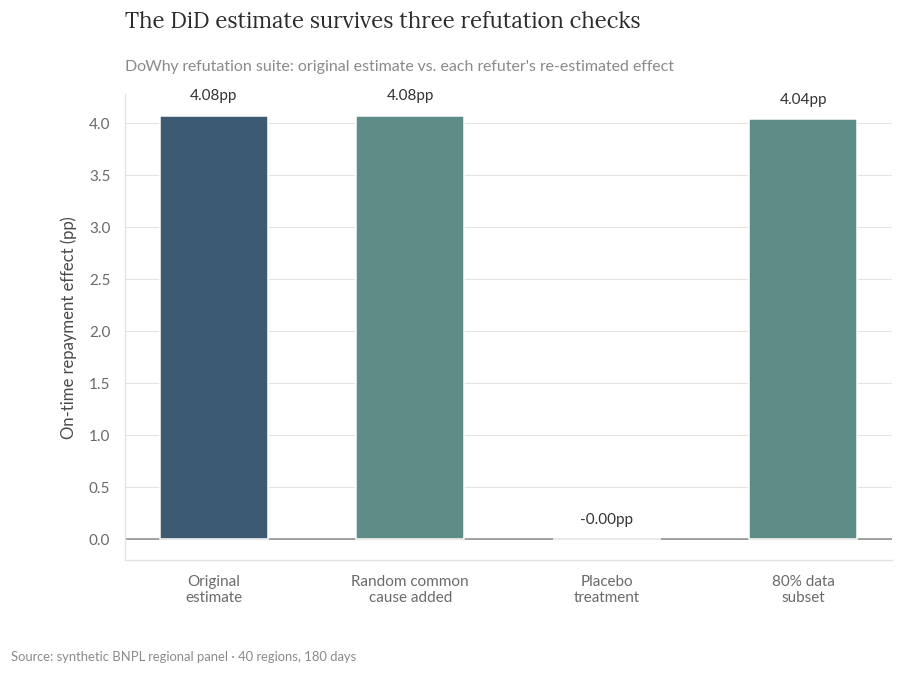

In [23]:
labels = ["Original\nestimate", "Random common\ncause added", "Placebo\ntreatment", "80% data\nsubset"]
values = [dowhy_estimate.value, refute_random_cause.new_effect, refute_placebo.new_effect, refute_subset.new_effect]
colors = [SLATE, MUTED_TEAL, MUTED_RED, MUTED_TEAL]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(labels, [v * 100 for v in values], color=colors, width=0.55, zorder=3)
for i, v in enumerate(values):
    y = v * 100
    label_y = y + 0.15 if y >= -0.1 else y - 0.4
    ax.text(i, label_y, f"{y:.2f}pp", ha="center", fontsize=10, color="#333")
ax.axhline(0, color=GREY, linewidth=1)
style_ax(ax, title="The DiD estimate survives three refutation checks",
         subtitle="DoWhy refutation suite: original estimate vs. each refuter's re-estimated effect",
         ylabel="On-time repayment effect (pp)")
add_footnote(fig, SOURCE_ROLLOUT)
plt.show()

**Figure 13.** DoWhy refutation suite: original estimate vs. each refuter's re-estimated effect.

The estimate barely moves when a random confounder is added or the data is subsetted, and collapses to essentially zero under a placebo treatment (Figure 13). DoWhy's significance test for the placebo refuter checks whether zero falls comfortably inside the distribution of placebo-simulated effects rather than whether the original estimate does, so the *non-significant* result there is the desired outcome: the placebo effects cluster around zero, as a placebo should.

## 4. RFM customer segmentation

Recency, frequency, and monetary value, log-transformed and standardized (their raw scales are wildly different and right-skewed), clustered with KMeans. The number of clusters is chosen by silhouette score rather than fixed in advance (Figure 14).

Selected k=3


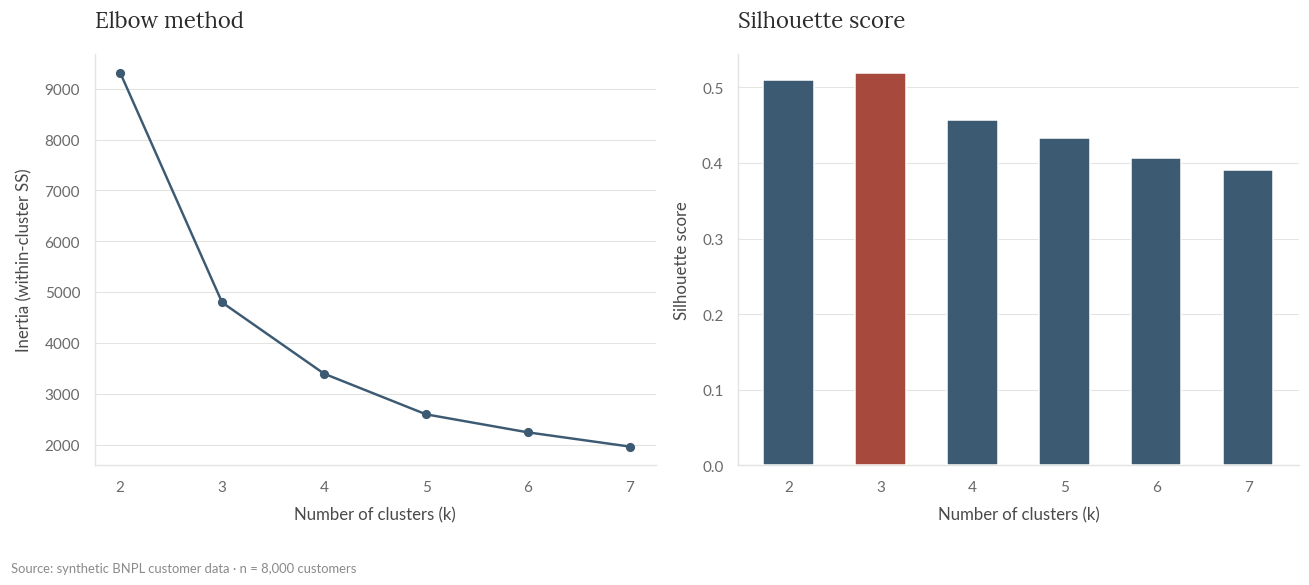

In [24]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

rfm_raw = pd.read_csv("../data/rfm_customers.csv")
SOURCE_RFM = f"Source: synthetic BNPL customer data · n = {len(rfm_raw):,} customers"

rfm = rfm_raw[["customer_id", "recency_days", "frequency", "monetary_usd"]].copy()
log_features = np.column_stack([np.log1p(rfm["recency_days"]), np.log1p(rfm["frequency"]), np.log1p(rfm["monetary_usd"])])
X = StandardScaler().fit_transform(log_features)

K_RANGE = range(2, 8)
inertias, sil_scores = [], []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=7, n_init=10).fit(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, km.labels_))

best_k = list(K_RANGE)[int(np.argmax(sil_scores))]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(list(K_RANGE), inertias, color=SLATE, marker="o", markersize=5, linewidth=1.6)
style_ax(axes[0], title="Elbow method", xlabel="Number of clusters (k)", ylabel="Inertia (within-cluster SS)")
colors = [MUTED_RED if k == best_k else SLATE for k in K_RANGE]
axes[1].bar([str(k) for k in K_RANGE], sil_scores, color=colors, zorder=3, width=0.55)
style_ax(axes[1], title="Silhouette score", xlabel="Number of clusters (k)", ylabel="Silhouette score")
plt.tight_layout()
add_footnote(fig, SOURCE_RFM)
plt.show()
print(f"Selected k={best_k}")

**Figure 14.** KMeans cluster selection: elbow method and silhouette score by k.

In [25]:
NAME_SETS = {2: ["Champions", "Dormant"], 3: ["Champions", "Loyal", "Dormant"],
             4: ["Champions", "Loyal", "At risk", "Dormant"],
             5: ["Champions", "Loyal", "Promising", "At risk", "Dormant"],
             6: ["Champions", "Loyal", "Promising", "At risk", "Lapsed", "Dormant"]}

km = KMeans(n_clusters=best_k, random_state=7, n_init=10).fit(X)
rfm["cluster"] = km.labels_
profile = rfm.groupby("cluster")[["recency_days", "frequency", "monetary_usd"]].mean()

r_rank = profile["recency_days"].rank()
f_rank = profile["frequency"].rank(ascending=False)
m_rank = profile["monetary_usd"].rank(ascending=False)
order = (r_rank + f_rank + m_rank).sort_values().index
names = NAME_SETS[best_k]
label_map = {seg: names[i] for i, seg in enumerate(order)}

rfm["segment"] = rfm["cluster"].map(label_map)
profile.index = profile.index.map(label_map)
profile = profile.reindex(names)
profile.round(1)

,recency_days,frequency,monetary_usd
cluster,,,
Champions,11.1,24.3,12547.3
Loyal,98.3,9.8,4094.2
Dormant,307.1,2.6,831.3


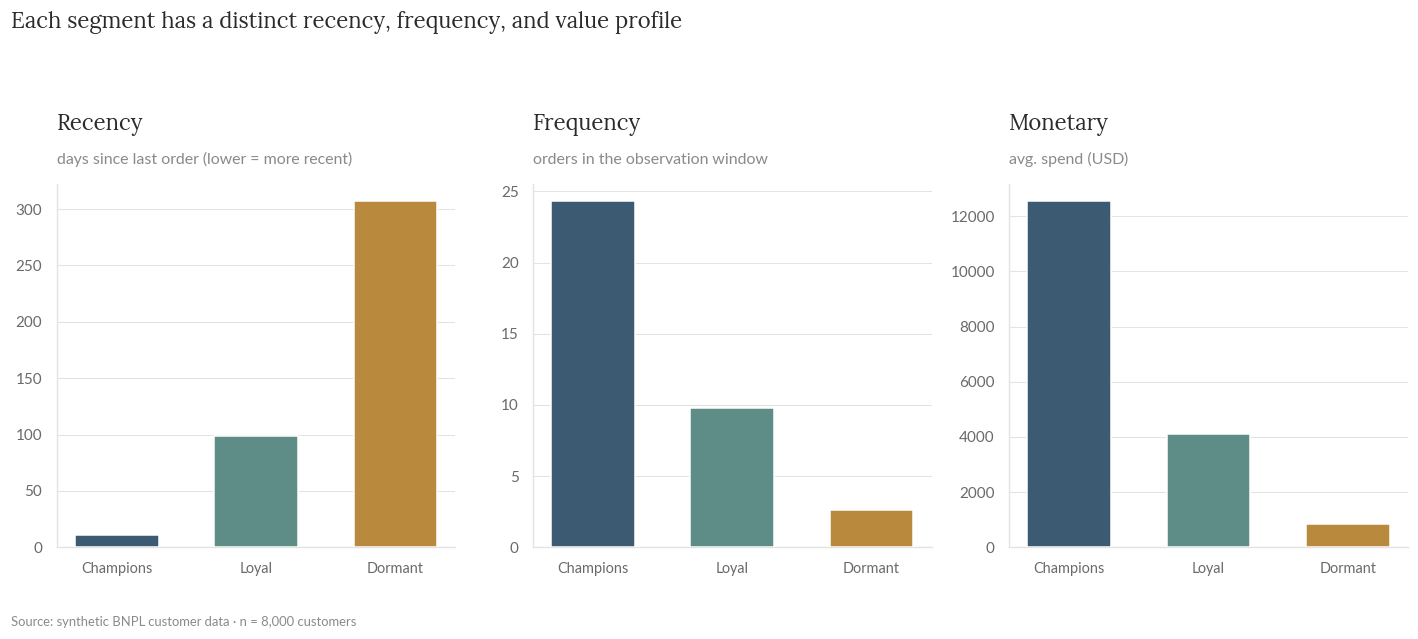

In [26]:
panels = [("recency_days", "Recency", "days since last order (lower = more recent)"),
          ("frequency", "Frequency", "orders in the observation window"),
          ("monetary_usd", "Monetary", "avg. spend (USD)")]
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, (col, label, sublabel) in zip(axes, panels):
    ax.bar(profile.index, profile[col], color=PALETTE[:len(profile)], width=0.6, zorder=3)
    style_ax(ax, title=label, subtitle=sublabel, grid_axis="y")
    ax.tick_params(axis="x", labelsize=9.5)
fig.suptitle("Each segment has a distinct recency, frequency, and value profile", x=0.01, y=1.06,
             ha="left", fontsize=14.5, fontfamily="Lora", color="#2B2B2B")
plt.tight_layout()
add_footnote(fig, SOURCE_RFM)
plt.show()

**Figure 15.** RFM segment profiles: recency, frequency, and monetary value by segment.

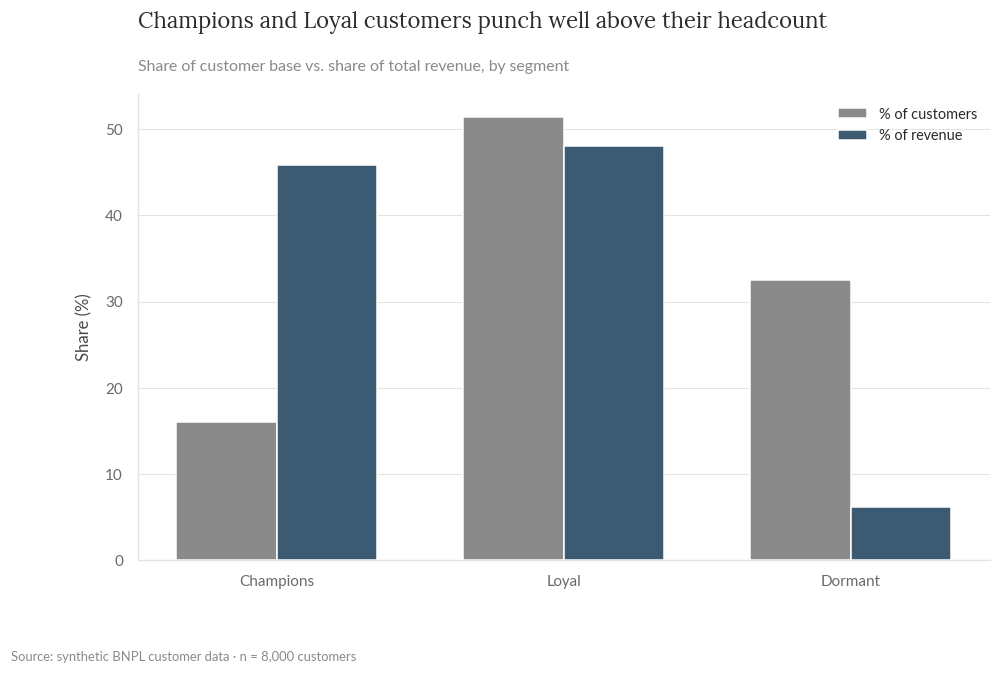

,customers,revenue,pct_customers,pct_revenue
cluster,,,,
Champions,1281,16073079.2,16.0,45.8
Loyal,4117,16855677.3,51.5,48.0
Dormant,2602,2163128.7,32.5,6.2


In [27]:
seg_summary = rfm.groupby("segment").agg(customers=("customer_id", "count"), revenue=("monetary_usd", "sum")).reindex(profile.index)
seg_summary["pct_customers"] = seg_summary["customers"] / seg_summary["customers"].sum() * 100
seg_summary["pct_revenue"] = seg_summary["revenue"] / seg_summary["revenue"].sum() * 100

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(seg_summary))
width = 0.35
ax.bar(x - width/2, seg_summary["pct_customers"], width, color=GREY, label="% of customers", zorder=3)
ax.bar(x + width/2, seg_summary["pct_revenue"], width, color=SLATE, label="% of revenue", zorder=3)
ax.set_xticks(x); ax.set_xticklabels(seg_summary.index)
style_ax(ax, title="Champions and Loyal customers punch well above their headcount",
         subtitle="Share of customer base vs. share of total revenue, by segment", ylabel="Share (%)")
ax.legend(loc="upper right", fontsize=9.5)
add_footnote(fig, SOURCE_RFM)
plt.show()
seg_summary.round(1)

**Figure 16.** Share of customers and share of revenue, by RFM segment.

Champions are 16% of customers and 46% of revenue; Dormant customers are nearly a third of the base and just 6% of revenue, the clearest target for a win-back offer.

## 5. Light NLP: support ticket topic modeling

TF-IDF vectorizes 1,500 synthetic support ticket texts, and NMF (non-negative matrix factorization) extracts latent topics, with the topic count chosen by reconstruction error (Figure 17). The synthetic data was generated from five known underlying categories; that ground truth is used once, purely as a validation check, since it's not something a real, unlabeled ticket queue would have.

Reconstruction error decreases smoothly with no sharp elbow; 5 topics is chosen as a reasonable
operational category count for a support team, then checked for coherence below.


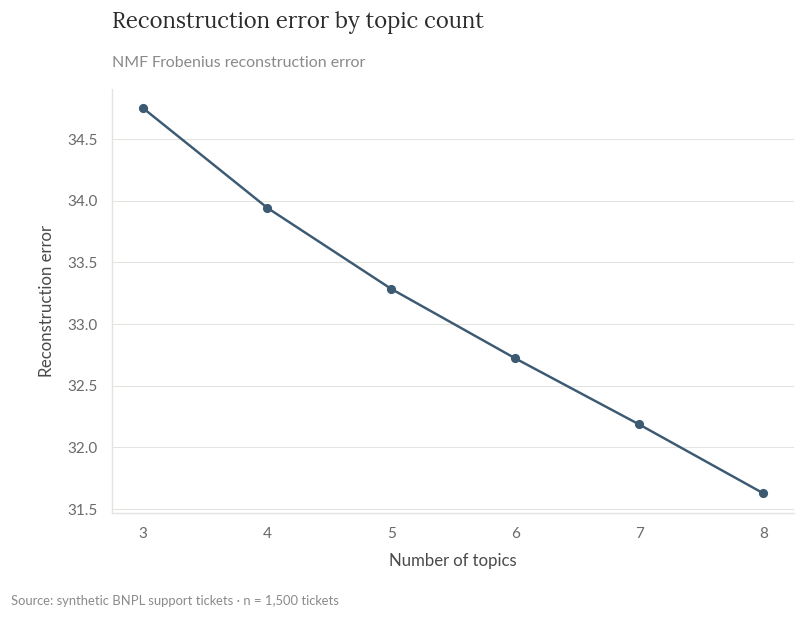

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

tickets = pd.read_csv("../data/support_tickets.csv")
SOURCE_TICKETS = f"Source: synthetic BNPL support tickets · n = {len(tickets):,} tickets"

vectorizer = TfidfVectorizer(stop_words="english", max_df=0.6, min_df=3, ngram_range=(1, 1))
X_text = vectorizer.fit_transform(tickets["ticket_text"])
feature_names = vectorizer.get_feature_names_out()

TOPIC_RANGE = range(3, 9)
errors = []
for k in TOPIC_RANGE:
    nmf_k = NMF(n_components=k, init="nndsvda", random_state=7, max_iter=400)
    nmf_k.fit(X_text)
    errors.append(nmf_k.reconstruction_err_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(TOPIC_RANGE), errors, color=SLATE, marker="o", markersize=5, linewidth=1.6)
style_ax(ax, title="Reconstruction error by topic count", subtitle="NMF Frobenius reconstruction error",
         xlabel="Number of topics", ylabel="Reconstruction error")
add_footnote(fig, SOURCE_TICKETS)
plt.show()
print("Reconstruction error decreases smoothly with no sharp elbow; 5 topics is chosen as a reasonable")
print("operational category count for a support team, then checked for coherence below.")

**Figure 17.** NMF reconstruction error by topic count.

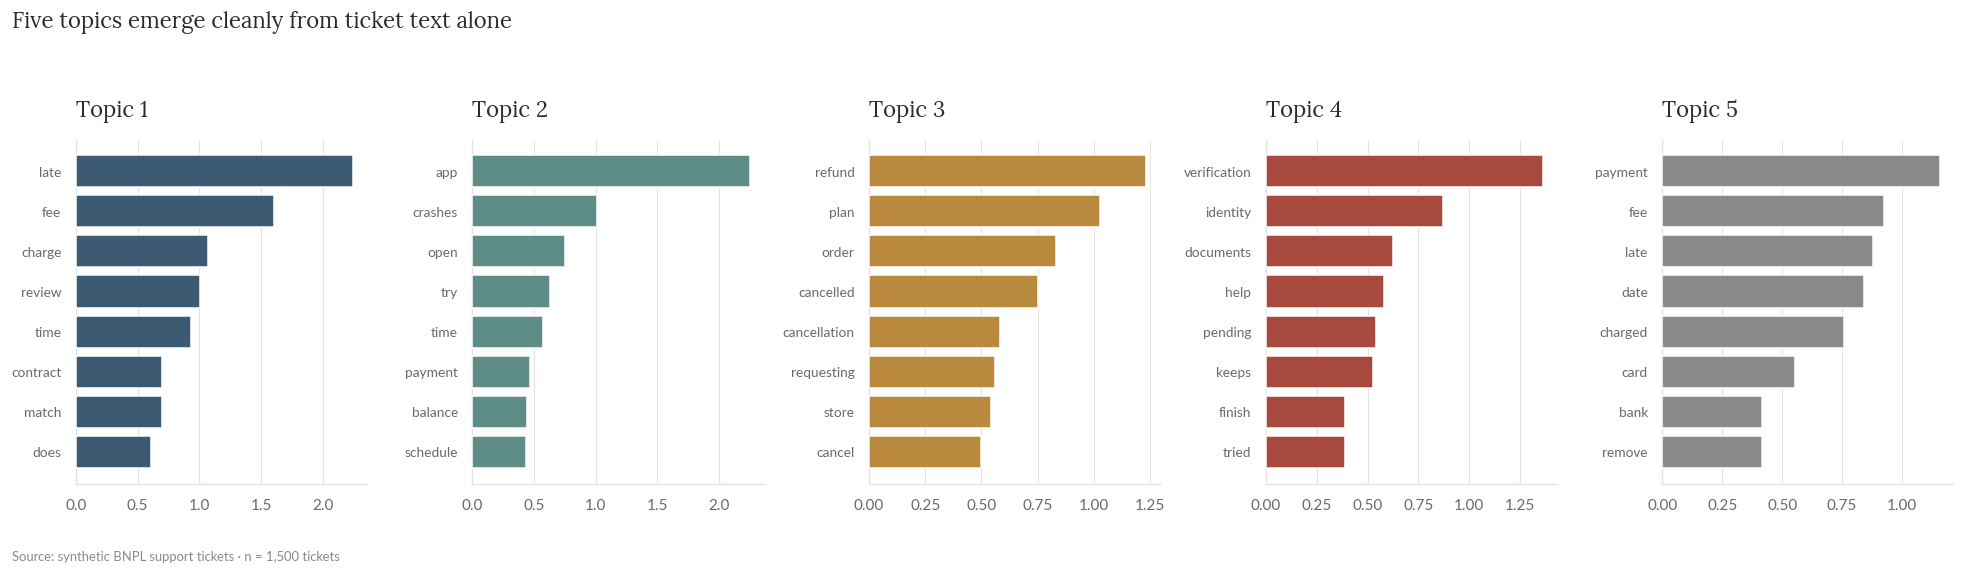

In [29]:
N_TOPICS = 5
nmf = NMF(n_components=N_TOPICS, init="nndsvda", random_state=7, max_iter=400)
W = nmf.fit_transform(X_text)
tickets["topic"] = W.argmax(axis=1)

fig, axes = plt.subplots(1, N_TOPICS, figsize=(18, 4.5))
for i, ax in enumerate(axes):
    comp = nmf.components_[i]
    top_idx = comp.argsort()[::-1][:8]
    ax.barh(range(8)[::-1], comp[top_idx], color=PALETTE[i % len(PALETTE)], zorder=3)
    ax.set_yticks(range(8)[::-1])
    ax.set_yticklabels([feature_names[j] for j in top_idx], fontsize=9)
    style_ax(ax, title=f"Topic {i+1}", grid_axis="x")
fig.suptitle("Five topics emerge cleanly from ticket text alone", x=0.01, y=1.05,
             ha="left", fontsize=14.5, fontfamily="Lora", color="#2B2B2B")
plt.tight_layout()
add_footnote(fig, SOURCE_TICKETS)
plt.show()

**Figure 18.** Top terms per recovered topic.

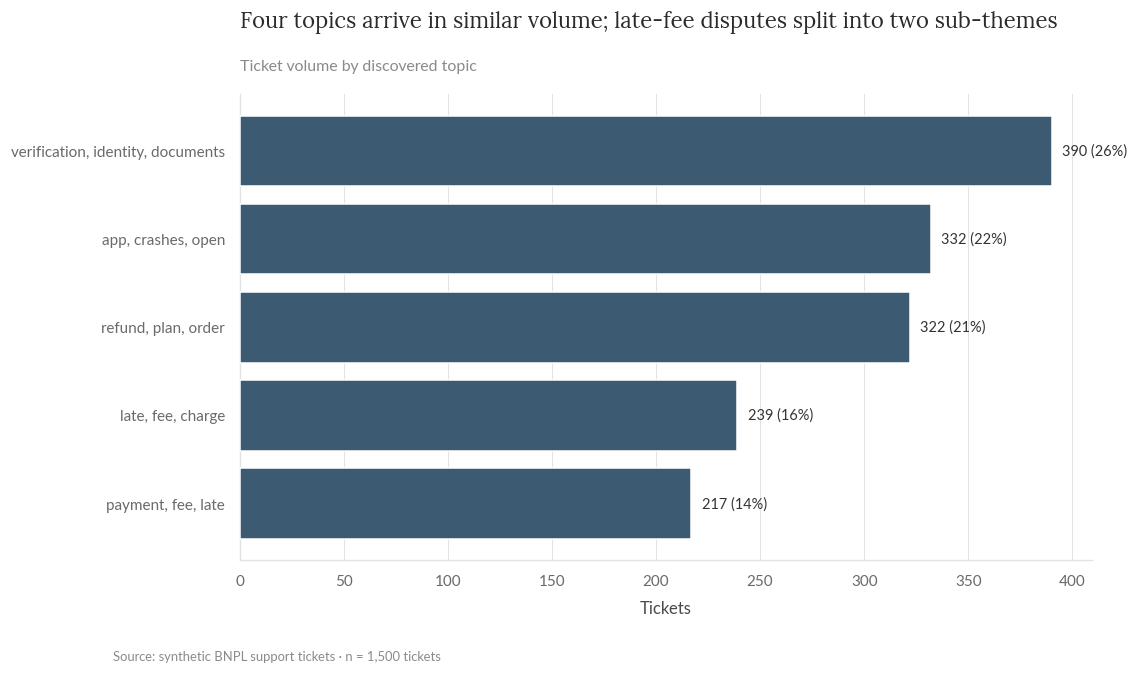

In [30]:
topic_labels = {i: ", ".join([feature_names[j] for j in nmf.components_[i].argsort()[::-1][:3]]) for i in range(N_TOPICS)}
tickets["topic_label"] = tickets["topic"].map(topic_labels)

vol = tickets["topic_label"].value_counts().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(vol.index, vol.values, color=SLATE, zorder=3)
for i, v in enumerate(vol.values):
    ax.text(v + 5, i, f"{v} ({v/len(tickets):.0%})", va="center", fontsize=9.5, color="#333")
style_ax(ax, title="Four topics arrive in similar volume; late-fee disputes split into two sub-themes",
         subtitle="Ticket volume by discovered topic", xlabel="Tickets", grid_axis="x")
add_footnote(fig, SOURCE_TICKETS)
plt.show()

**Figure 19.** Ticket volume by recovered topic.

In [31]:
cross = pd.crosstab(tickets["true_topic"], tickets["topic"])
match = cross.idxmax(axis=0)
purity = sum(cross.loc[match[t], t] for t in cross.columns) / len(tickets)
print(f"Cluster purity vs. ground-truth topic (synthetic data validation only): {purity:.1%}")
cross

Cluster purity vs. ground-truth topic (synthetic data validation only): 85.1%


topic,0,1,2,3,4
true_topic,,,,,
app_bug,0,325,0,0,0
general_inquiry,7,7,71,118,20
kyc_verification,0,0,0,272,0
late_fee_dispute,232,0,0,0,197
refund_request,0,0,251,0,0


Purity of 85% is a solid recovery of the underlying structure from text alone (Figure 18, Figure 19). The confusion is concentrated in `general_inquiry`, which scatters across several discovered topics rather than forming a distinct one of its own. That's a sensible failure mode, general questions about credit limits, interest, and rewards share vocabulary with the other categories rather than having a distinct lexical signature. In a real deployment, that topic would likely need a rule-based fallback or a supervised layer on top of the unsupervised topics rather than relying on NMF alone.

## 6. Limitations

- The A/B test, RFM segmentation, and topic modeling all use synthetic data engineered to have reasonably clean underlying structure. Real data is messier: real experiments have novelty effects and network interference between users, real customer bases have more continuous behavior than discrete archetypes, and real support tickets have far more lexical variety than a small set of templates.
- The regional rollout's parallel-trends check only covers the observed pre-period; it can't rule out an unobserved shock that happened to coincide with the rollout date in treated regions.
- CUPED's variance reduction depends on how correlated the pre-period covariate is with the outcome; a weaker covariate would produce a smaller (or negligible) gain.
- The uplift model's T-learner needed heavy leaf regularization (`min_samples_leaf=120`) and a log-scaled tenure feature to recover the heterogeneity reliably; an under-regularized version of the same model mostly estimated noise, since a T-learner takes the difference of two independently-fit models and that difference amplifies whatever noise each one picks up individually. The CausalForestDML comparison above backs that claim with a direct measurement: same split, same covariates, and a materially higher Qini coefficient.
- The topic model's `general_inquiry` category not forming its own cluster is a real limitation of unsupervised NMF on short, templated text.